# Learning the control: optimizing a linear feedback control


This notebook demonstrates how to optimize a simple feedback control by computing gradients through `DiscreteControlLoopSimulator`
We use:
1. a simple 1D linear-Gaussian dynamical system (a noisy random walk, `x_{k+1} = A x_k + B u_k + noise`) with the full state directly observed under Gaussian noise,
2. a linear feedback policy `u_k = -K x_hat_k` that drives the state toward 0,
3. a plot comparing the controlled trajectory against an uncontrolled (`K=0`) baseline.

In [1]:
import equinox as eqx
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpyro
import numpyro.distributions as dist
from numpyro.handlers import seed

import dynestyx as dsx
from dynestyx.control.discrete_controller_simulators import DiscreteControlLoopSimulator, filter_state_mean
from dynestyx.inference.configs.filter import KFConfig
from dynestyx.models import DynamicalModel
from dynestyx.models.observations import LinearGaussianObservation
from dynestyx.models.state_evolution import LinearGaussianStateEvolution


import jax
import optax
from optax import sgd, adam

## 1. Define the dynamics

`state_dim = control_dim = observation_dim = 1`. The transition is `x_{k+1} = A x_k + B u_k + noise`, with `A = 1` -- a marginally-unstable random walk when uncontrolled, so the effect of feedback control is visually obvious. The observation model directly observes the full state under additive Gaussian noise (`H = I`, no control dependence).

In [2]:
state_dim = control_dim = obs_dim = 2

dynamics = DynamicalModel(
    initial_condition=dist.MultivariateNormal(jnp.array([0.0, 0.0]), 5.0 * jnp.eye(state_dim)),
    state_evolution=LinearGaussianStateEvolution(
        A=jnp.eye(state_dim), B=jnp.eye(control_dim), cov=0.05 * jnp.eye(state_dim)
    ),
    observation_model=LinearGaussianObservation(
        H=jnp.eye(obs_dim, state_dim), R=0.2 * jnp.eye(obs_dim)
    ),
    control_dim=control_dim,
)

## 2. Define the controller

A simple linear feedback policy `u = -K x_hat`, implemented as an `equinox.Module`.

In [3]:
class LinearPolicy(eqx.Module):
    K: jnp.ndarray

    def __call__(self, x_hat, s, key):
        return -self.K @ filter_state_mean(x_hat), s

## 3. Differentiating through the closed loop

`DiscreteControlLoopSimulator` is pure JAX under the hood and so we can compute gradients. Since this doesn't need NumPyro's tracing machinery (no conditioning, no MCMC), we call `sim.simulate(dynamics, rng_key=..., predict_times=...)` directly instead of going through `dsx.sample`/`numpyro.handlers.seed` -- this makes the PRNG key explicit, which matters once we optimize `K` over many epochs in section 4: each epoch gets a fresh key rather than reusing the same fixed noise realization, so the optimizer can't simply overfit `K` to one specific trajectory.

In [17]:
predict_times_short = jnp.arange(0.0, 5.0)


def rollout_final_state_norm(K, key):
    policy = LinearPolicy(K=K)
    sim = DiscreteControlLoopSimulator(
        control_policy=policy,
        policy_state_init=None,
        filter_config=KFConfig(filter_source="cuthbert"),
    )
    result = sim.simulate(dynamics, rng_key=key, predict_times=predict_times_short)
    final_state = result.states[0, -1, :]
    return jnp.linalg.norm(final_state)


K0 = jnp.eye(state_dim) * 1e-1
key0 = jax.random.PRNGKey(0)
loss_value = rollout_final_state_norm(K0, key0)
grad_K = jax.grad(rollout_final_state_norm)(K0, key0)
print("Initial loss value:", loss_value)
print("Gradient of loss w.r.t K:", grad_K)

Initial loss value: 5.538885
Gradient of loss w.r.t K: [[-14.676369 -10.56624 ]
 [ -8.130766  -5.853739]]


In [18]:
# Finite-difference check for one entry of K (K[0, 0]) which confirms the
# autodiff gradient through the whole closed loop is correct.
eps = 1e-3
K_plus = K0.at[0, 0].add(eps)
K_minus = K0.at[0, 0].add(-eps)
finite_diff = (
    rollout_final_state_norm(K_plus, key0) - rollout_final_state_norm(K_minus, key0)
) / (2 * eps)

print(f"autodiff grad_K[0, 0]:       {grad_K[0, 0]:.6f}")
print(f"finite-difference estimate: {finite_diff:.6f}")
assert jnp.allclose(grad_K[0, 0], finite_diff, atol=1e-3)
print("OK: matches within tolerance")

autodiff grad_K[0, 0]:       -14.676369
finite-difference estimate: -14.676332
OK: matches within tolerance


# 4. Optimizing the controller

Here we optimize the control matrix $K$ by unrolling forward over a short time and sampling a new initial condition at each optimization step.

In [19]:
epochs = 100
learning_rate = 1e-2
losses = []

optimizer = adam(learning_rate)
K_opt = jnp.copy(K0)
optim_state = optimizer.init(K_opt)
key = jax.random.PRNGKey(0)
for epoch in range(epochs):
    key, subkey = jax.random.split(key)
    loss_value = rollout_final_state_norm(K_opt, subkey)
    grad_K = jax.grad(rollout_final_state_norm)(K_opt, subkey)

    updates, optim_state = optimizer.update(grad_K, optim_state)
    K_opt = optax.apply_updates(K_opt, updates)

    if epoch % 10 == 0:
        print(f"Epoch {epoch}: Loss={loss_value:.4f}, K={K_opt}")
    losses.append(loss_value)

Epoch 0: Loss=2.6394, K=[[0.10999993 0.00999993]
 [0.00999993 0.10999993]]
Epoch 10: Loss=2.1864, K=[[ 0.17811827 -0.01132447]
 [-0.0058398   0.17027593]]
Epoch 20: Loss=1.1784, K=[[ 0.2542053  -0.01834987]
 [-0.03070187  0.23029748]]
Epoch 30: Loss=0.8324, K=[[ 0.3045337   0.00152742]
 [-0.02864028  0.29052168]]
Epoch 40: Loss=0.3923, K=[[ 0.35525057  0.0017233 ]
 [-0.01739779  0.3305604 ]]
Epoch 50: Loss=1.0520, K=[[ 0.40615872 -0.00147044]
 [-0.01411944  0.37170437]]
Epoch 60: Loss=1.3664, K=[[ 0.43990442  0.01074153]
 [-0.00952533  0.4138038 ]]
Epoch 70: Loss=0.4713, K=[[ 0.46063015  0.01035106]
 [-0.02110424  0.4399218 ]]
Epoch 80: Loss=0.4863, K=[[ 0.48730075  0.02812148]
 [-0.0194033   0.45730466]]
Epoch 90: Loss=0.3954, K=[[ 0.49853238  0.03747003]
 [-0.01219637  0.46724102]]


Text(0, 0.5, 'Loss (||x_T||)')

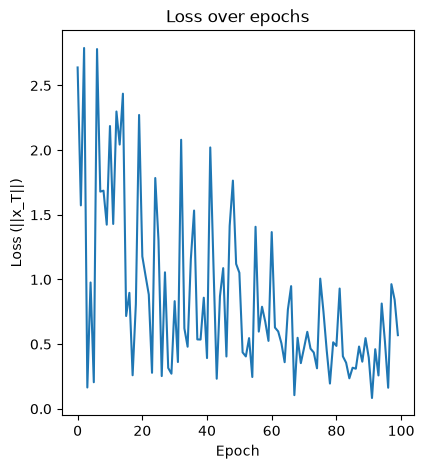

In [20]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(losses)
plt.title("Loss over epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss (||x_T||)")    

We now run the loop with both the initial and optimized K to compare results. Our optimized controller drives the system to zero much more quickly compared to the initial controller we chose.

In [ ]:
predict_times = jnp.arange(0.0, 30.0)


def run(K, key):
    policy = LinearPolicy(K=K)
    sim = DiscreteControlLoopSimulator(
        control_policy=policy,
        policy_state_init=None,
        filter_config=KFConfig(filter_source="cuthbert"),
    )
    result = sim.simulate(dynamics, rng_key=key, predict_times=predict_times)
    return result

trace_unopt = run(K0, key0)
trace_opt = run(K_opt, key0)

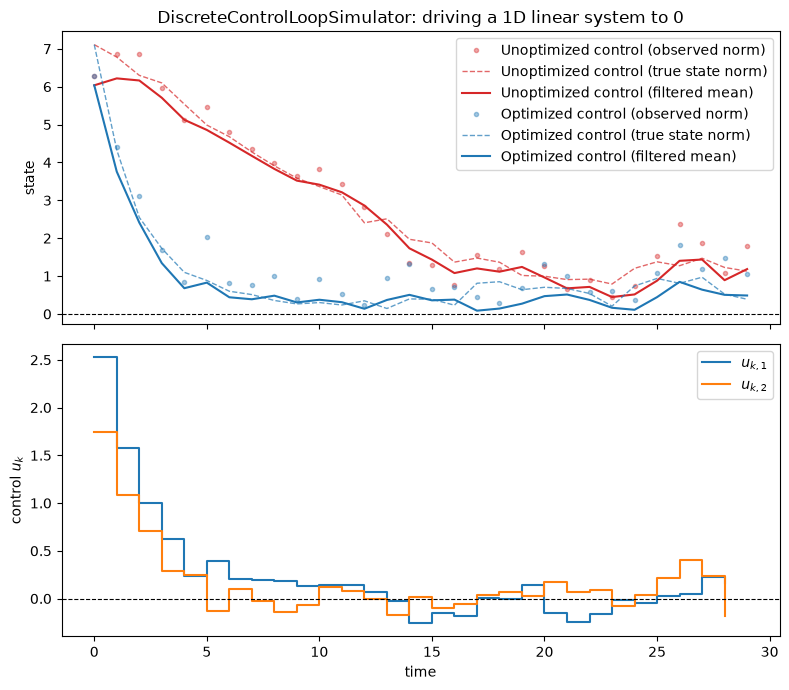

In [ ]:

fig, axes = plt.subplots(2, 1, figsize=(8, 7), sharex=True)

runs = [
    (trace_unopt, "Unoptimized control", "tab:red"),
    (trace_opt, "Optimized control", "tab:blue"),
]
for result, label, color in runs:
    t = result.times[0]
    true_state = jnp.linalg.norm(result.states[0, :], axis=-1)
    obs = jnp.linalg.norm(result.observations[0, :], axis=-1)
    filtered_mean = jnp.linalg.norm(result.filtered_states_mean[0, :], axis=-1)
    axes[0].plot(t, obs, ".", color=color, alpha=0.4, label=f"{label} (observed norm)")
    axes[0].plot(t, true_state, "--", color=color, alpha=0.7, linewidth=1, label=f"{label} (true state norm)")
    axes[0].plot(t, filtered_mean, "-", color=color, label=f"{label} (filtered mean)")

axes[0].axhline(0.0, color="black", linewidth=0.8, linestyle="--")
axes[0].set_ylabel("state")
axes[0].legend()
axes[0].set_title("DiscreteControlLoopSimulator: driving a 1D linear system to 0")

t_u = trace_opt.times[0][:-1]
u_1 = trace_opt.controls[0, :, 0]
u_2 = trace_opt.controls[0, :, 1]

axes[1].step(t_u, u_1, where="post", color="tab:blue", label="$u_{k,1}$")
axes[1].step(t_u, u_2, where="post", color="tab:orange", label="$u_{k,2}$")
axes[1].axhline(0.0, color="black", linewidth=0.8, linestyle="--")
axes[1].legend()
axes[1].set_ylabel("control $u_k$")
axes[1].set_xlabel("time")

plt.tight_layout()
plt.show()